In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 

sys.path.append(os.path.join(project_root, 'Scripts'))

import pandas as pd

pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from data_utils.processing import FeatureEngineer

In [2]:
data = (pd.read_parquet(config.TIDY_DATA_PATH))
data = data.reset_index(drop=True)


In [3]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float64)

    return df

In [4]:
data = numpy_dtypes(data)

In [5]:
data.dtypes.head()

name            str
position        str
team            str
xP          float64
assists     float64
dtype: object

In [6]:
data.columns = data.columns.str.lower()

In [7]:
#data.drop(columns=["understat", "date"], inplace=True)

In [8]:
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00,0.0,0.0,0.0,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,2223.0,32.0,11948.0,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00,0.0,0.0,0.0,0.0,0.0,33.0,0.0,33.0,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,2223.0,33.0,11948.0,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00,0.0,0.0,0.0,0.0,0.0,34.0,0.0,84.0,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,2223.0,34.0,11948.0,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00,0.0,0.0,0.0,0.0,0.0,35.0,0.0,111.0,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,2223.0,35.0,11948.0,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00,0.0,0.0,0.0,0.0,0.0,36.0,0.0,134.0,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,2223.0,36.0,11948.0,0.0,0.0,0.0,0.0


In [9]:
data.isna().sum().sum()

np.int64(0)

In [10]:
data["transfers_trend"] = (data.transfers_balance / data.selected).replace([np.inf, -np.inf], np.nan).fillna(0)

In [11]:
data.shape

(100409, 46)

In [12]:
target = ["total_points"]

id_cols = ["name", "element", "kickoff_time", "gw", "code", "season"]

static_cols = ["position", "was_home", "starts"]

fpl_cols = ["bonus", "bps", "ict_index", "influence", "value", "threat"] + list(set([c for c in data.columns if "transfers" in c or "selected" in c]))

perf_cols = list(set([c for c in data.columns if c not in target + id_cols + static_cols + fpl_cols]))

In [13]:
list(perf_cols)

['own_goals',
 'xg_per_90',
 'red_cards',
 'round',
 'xg',
 'xg_conceded_per_90',
 'yellow_cards',
 'xg_conceded',
 'team_a_score',
 'team_h_score',
 'xg_involvements_per_90',
 'creativity',
 'xp',
 'penalties_missed',
 'minutes',
 'clean_sheets',
 'saves',
 'xg_involvements',
 'penalties_saved',
 'team',
 'xa_per_90',
 'goals_conceded',
 'xa',
 'goals_scored',
 'assists']

In [14]:
data.shape[1], len(target + id_cols + static_cols + fpl_cols + perf_cols)

(46, 46)

In [15]:
[c for c in target + id_cols + static_cols + fpl_cols + perf_cols if c not in data.columns]

[]

In [16]:
feature_eng = FeatureEngineer(df=data)
data_lag = feature_eng.features_integration()

In [17]:
data_lag.head()

,transfers_in,position,element,gw,code,season,transfers_balance,was_home,name,selected,transfers_out,value,transfers_trend,kickoff_time,total_points,bonus_ema_8,bps_ema_8,ict_index_ema_8,influence_ema_8,value_ema_8,threat_ema_8,selected_ema_8,transfers_out_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_trend_ema_8,yellow_cards_ema_8,xg_conceded_per_90_ema_8,clean_sheets_ema_8,minutes_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xa_per_90_ema_8,own_goals_ema_8,assists_ema_8,xg_ema_8,saves_ema_8,penalties_saved_ema_8,xp_ema_8,penalties_missed_ema_8,goals_scored_ema_8,team_h_score_ema_8,xa_ema_8,xg_involvements_ema_8,team_a_score_ema_8,goals_conceded_ema_8,creativity_ema_8,xg_conceded_ema_8,red_cards_ema_8,total_points_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,value_lagged_1,threat_lagged_1,selected_lagged_1,transfers_out_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_trend_lagged_1,yellow_cards_lagged_1,xg_conceded_per_90_lagged_1,clean_sheets_lagged_1,minutes_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xa_per_90_lagged_1,own_goals_lagged_1,assists_lagged_1,xg_lagged_1,saves_lagged_1,penalties_saved_lagged_1,xp_lagged_1,penalties_missed_lagged_1,goals_scored_lagged_1,team_h_score_lagged_1,xa_lagged_1,xg_involvements_lagged_1,team_a_score_lagged_1,goals_conceded_lagged_1,creativity_lagged_1,xg_conceded_lagged_1,red_cards_lagged_1,total_points_lagged_1
0,0.0,GK,760.0,32.0,11948.0,2223.0,0.0,False,Andy Lonergan,0.0,0.0,4.0,0.000000,2023-04-22T14:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18.0,GK,760.0,33.0,11948.0,2223.0,17.0,True,Andy Lonergan,33.0,1.0,4.0,0.515152,2023-04-27T18:45:00,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.500000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25.0,GK,760.0,34.0,11948.0,2223.0,19.0,False,Andy Lonergan,84.0,6.0,4.0,0.226190,2023-05-01T19:00:00,0.0,0.0,0.0,0.0,0.0,4.0,0.0,7.333333,0.222222,3.777778,4.000000,0.114478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.055556,0.0,0.0,0.222222,0.0,0.0,0.888889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,33.0,1.0,17.0,18.0,0.515152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
3,32.0,GK,760.0,35.0,11948.0,2223.0,11.0,False,Andy Lonergan,111.0,21.0,4.0,0.099099,2023-05-08T16:30:00,0.0,0.0,0.0,0.0,0.0,4.0,0.0,24.370370,1.506173,7.160494,8.666667,0.139303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.820988,0.0,0.0,0.617284,0.0,0.0,1.135802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,84.0,6.0,19.0,25.0,0.226190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,22.0,GK,760.0,36.0,11948.0,2223.0,-3.0,True,Andy Lonergan,134.0,25.0,4.0,-0.022388,2023-05-14T13:00:00,0.0,0.0,0.0,0.0,0.0,4.0,0.0,43.621399,5.838134,8.013717,13.851852,0.130369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.638546,0.0,0.0,0.702332,0.0,0.0,1.994513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,111.0,21.0,11.0,32.0,0.099099,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0


In [18]:
data_lag.isna().sum().sum()

np.int64(0)

In [19]:
data_lag.shape

(100409, 85)

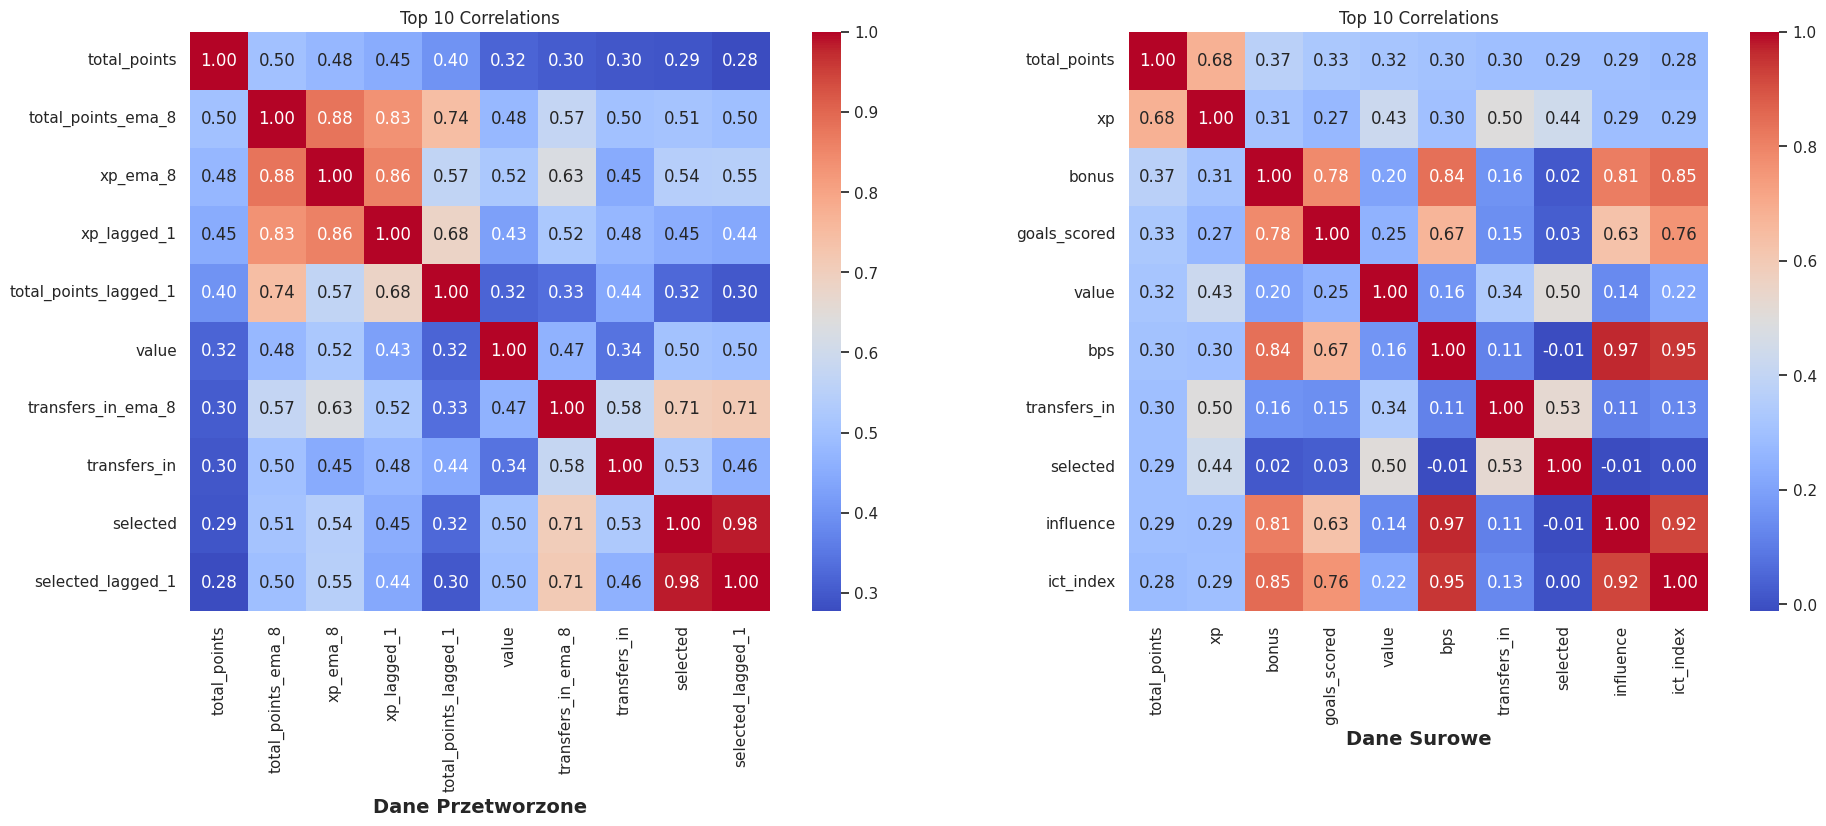

In [20]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["total_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lag, data], ["Dane Przetworzone", "Dane Surowe"])

In [21]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.drop(columns=["total_points"], errors="ignore").select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [22]:
pairs_list = over_corr_pairs(data_lag, threshold=0.9)
pairs = pd.DataFrame(pairs_list)

if not pairs.empty:
    cols_to_drop = pairs[1].unique()
    data_lag.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Usunięto {len(cols_to_drop)} silnie skorelowanych kolumn.")
else:
    print("Nie znaleziono silnie skorelowanych kolumn do usunięcia.")

Usunięto 31 silnie skorelowanych kolumn.


In [23]:
data_lag.shape

(100409, 54)

In [24]:
data_lag.to_parquet(config.FPL_DATA_PATH,
                index=False)